## Before You Get Started Check-List

Before starting work on the competition, it’s recommended to go through the following steps to understand the setup, data, and submission expectations.

---

### 1. Read the Competition Page in Detail

Begin with the **Overview** and **Data** tabs on the competition page.

In particular, read the **Evaluation and Submission Guide** section carefully.

---

### 2. Review the Rules Page (Especially Sections 6–9)

Next, go through the **Rules** page, with special attention to **Sections 6, 7, 8, and 9**, which are especially relevant for this competition.

Key points to keep in mind:
- Submissions are expected to be **Notebook/Code Only**.
- Only the **competition-provided data** should be used.
- Each submission should include the **link to the exact notebook (version-sensitive)** used to generate it in the submission description.
- The notebook may be private, but it must be **shared with the competition host accounts**(host usernames-rahulsundar, sanchitbedi, siddharthandileep) so results can be reviewed and reproduced.

Reading the full rules is important to avoid issues during evaluation or shortlisting.

---

### 3. Go Through the Helper Notebook

The provided **helper notebook** is designed to guide you through the competition setup and data.

It contains instructions covering:
- Kaggle compute environment and runtime constraints
- Connecting and working with the provided GitHub repository
- Understanding the Data
- Creating train/validation time-series samples
- Test Input Format
- An overview of a complete end-to-end notebook pipeline
- Practical training tips and recommendations

It will help you get oriented before implementing your own approach.

---

### 4. Review the Baseline Repository

A baseline code repository is provided.

It’s useful to:
- Read the repository **README**
- Understand the expected pipeline and code organization

This step is optional, but can serve as a helpful reference when building your own solution.

---

### 5. Get Started

You’re ready now to start developing your own solution for the competition.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/psfc.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/t2.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/SO2.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/NMVOC_finn.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/bio.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/rain.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/u10.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/swdown.npy
/kaggle/input/competitions/anrf-aise-hack-pha

## ‼️ Add **'anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd'** competition dataset as an input and before running the cells

In [2]:
# where all input datasets are stored
os.listdir('/kaggle/input/')

['competitions']

In [3]:
# different input data folders provided
os.listdir('/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/')

['test_in', 'stats', 'raw']

In [4]:
# current working directory
os.getcwd()

'/kaggle/working'

## 1. Kaggle Notebook Compute & Storage Constraints

### Accelerator Types

| Accelerator   | Hardware             | Notebook RAM | Notes                             |
| ------------- | -------------------- | ------------ | --------------------------------- |
| **GPU P100**  | 1× NVIDIA Tesla P100 | **~30 GB**   | Single GPU                        |
| **GPU T4 x2** | 2× NVIDIA T4         | **~30 GB**   | Dual GPU, same quota pool as P100 |
| **TPU v5e-8** | 8 TPU v5e cores      | **~330 GB**  | Very high RAM TPU VM              |

---

### Weekly Accelerator Quotas

| Resource | Weekly Limit |
|----------|---------------|
| **GPU (P100 + T4x2 combined)** | ~30 hours / week |
| **TPU** | ~20 hours / week |

> All GPU types share the same 30-hour pool.

---

### Maximum Runtime Per Session

| Mode                          | Listed Max Continuous Runtime |
| ----------------------------- | ----------------------------- |
| **CPU Only (No accelerator)** | ~**12 hours**                 |
| **GPU Notebook**              | **~12 hours**                 |
| **TPU Notebook**              | **~9 hours**                  |

---

### RAM Available

| Mode | RAM |
|------|-----|
| **CPU Only** | **~30 GB** |
| **GPU (P100 / T4x2)** | **~30 GB** |
| **TPU v5e-8** | **~330 GB** |

---

### Disk & Write Limits

| Mode         | Writable Disk (listed) | Practical Upper Limit | `/kaggle/working` | /kaggle/temp |
| ------------ | ---------------------- | --------------------- | ----------------- | ------------ |
| **CPU Only** | ~57 GB                 | ~100 GB               | **20 GB**         |              |
| **GPU**      | ~57 GB                 | ~100 GB               | **20 GB**         |              |
| **TPU**      | ~40 GB                 | ~100 GB               | **20 GB**         |              |

### Important Behavior
- Only files inside **`/kaggle/working` (20 GB)** are saved after commit.
- You can temporarily write much more data during the session (close to ~100 GB), but it is deleted when the session ends unless moved to `/kaggle/working`.

## 2. Connecting a GitHub Repository as a Dataset and Calling Scripts from It

- In the Kaggle notebook interface, in the Input Sectionclick on **Upload → New Dataset**.
- Choose the option to upload from a **Link and Import GitHub repository** and provide the repository URL(must be public repository).
- Kaggle will package the repository contents as a dataset, ask you to name it and attach it to your account.
- Once attached, the repository will be available to the notebook as an **input dataset**, and all scripts and files can be accessed directly from the mounted input directory.
- You can then import modules or execute scripts from this dataset just like local files if it has been added to input.
- This is exactly how the **[Baseline Notebook](https://www.kaggle.com/code/siddharthandileep/phase2-baseline-run-aisehack/)** posted as reference works with **[Baseline Code Github Repo](https://github.com/vaasew/baseline_aisehackt2_phase2)**

- If changes are made to the remote GitHub repository and you want them to be reflected in Kaggle:
  - Navigate to the dataset’s page on Kaggle.
  - Use the Update dataset to pull the latest version from the GitHub repository.(You can even set periodic auto-updates)
  - Return to the notebook and click **Check for updates** on it's input dataset to sync the latest changes.
- This workflow allows you to maintain a single source of truth in GitHub while iterating seamlessly within Kaggle notebooks.


## 3. Understanding the raw data

In [5]:
data_files='/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/'

# loading different features, you can refer to Data section of the competition webpage for insight into what each feature signifies
cpm=np.load(os.path.join(data_files,'raw','APRIL_16','cpm25.npy')) # pm concentrations
t2=np.load(os.path.join(data_files,'raw','APRIL_16','t2.npy')) # temperature
time=np.load(os.path.join(data_files,'raw','APRIL_16','time.npy')) # timestamp
rain=np.load(os.path.join(data_files,'raw','APRIL_16','rain.npy')) # rain

print(time[0])
# time is UTC

2016-04-01T00:00:00


In [6]:
print(time[-1])

print(cpm.shape)
print(t2.shape)
print(rain.shape)

#shape => (hour,latitudes,longitudes)
#you can view it as an hourly image of the subcontinent
#all features are aligned in time and space

2016-04-30T18:00:00
(715, 140, 124)
(715, 140, 124)
(715, 140, 124)


2016-04-01T00:00:00


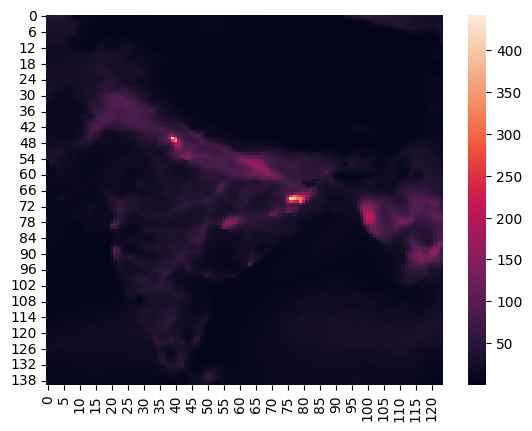

In [7]:
import seaborn as sns
sns.heatmap(cpm[0,::-1,:])
print(time[0])

2016-04-02T21:00:00


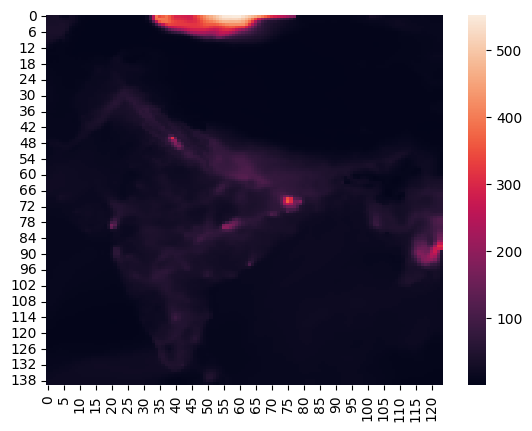

In [8]:
sns.heatmap(cpm[45,::-1,:])
print(time[45]

2016-04-01T06:00:00


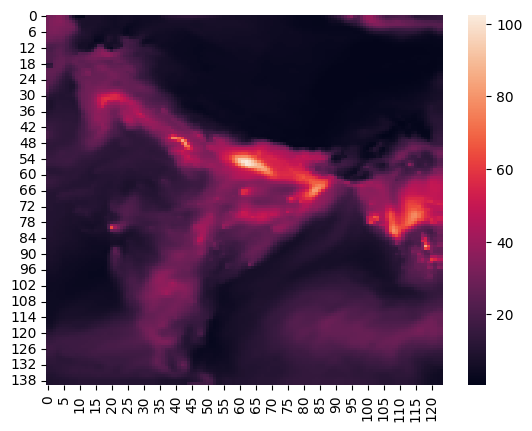

In [9]:
sns.heatmap(cpm[6,::-1,:])
print(time[6])

2016-04-03T12:00:00


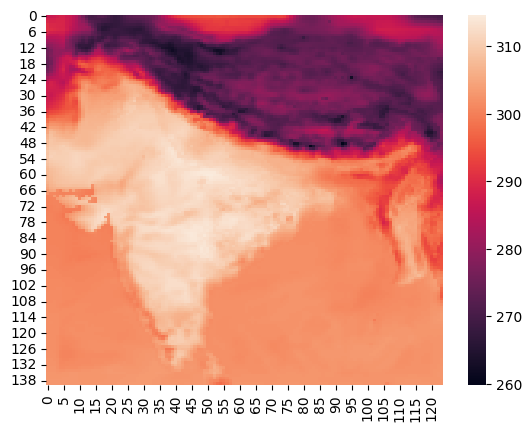

In [10]:
sns.heatmap(t2[60,::-1,:])
print(time[60])

2016-04-01T06:00:00


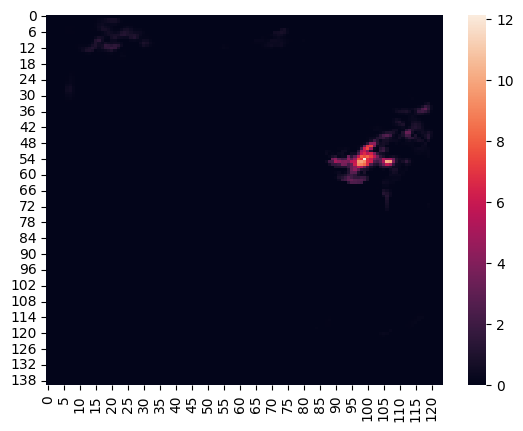

In [11]:
sns.heatmap(rain[6,::-1,:])
print(time[6])